# Clock Conversion Pipeline
Runs `pipeline/full_pipeline.py` — three modes:
1. **Single** — one digital + one analog image → output
2. **Batch** — random test-set samples side-by-side
3. **Animate** *(bonus)* — live clock ticking at real time

In [6]:
import os, sys

# Always run from the project root regardless of notebook location
PROJECT_ROOT = os.path.dirname(os.path.abspath('.'))
if os.path.basename(os.getcwd()) != 'DL-Project':
    os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), 'DL-Project'))
PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

os.makedirs('results', exist_ok=True)
print('Working dir:', PROJECT_ROOT)

Working dir: /home/liorb/Documents/Projects/DL-Project


In [7]:
from pipeline.full_pipeline import ClockPipeline, run_single, run_batch, run_animate
print('Pipeline imported OK')

Pipeline imported OK


## Config — edit paths here

In [8]:
READER_CKPT = 'src/checkpoints/digital_reader_best.pth'
ERASER_CKPT = 'src/checkpoints/eraser_v2_best.pth'
DATA_DIR    = 'src/clock_dataset'

# Matched pair (same timestamp prefix = same time on both clocks)
DIGITAL_IMG = 'src/clock_dataset/test/digital/00_25_39_00110_dig_simple.png'
ANALOG_IMG  = 'src/clock_dataset/test/analog/00_25_39_00110_ana_clean_square_orange_warm.png'

## Mode 1 — Single image pair

Loading pipeline on cpu ...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/liorb/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 15.7MB/s]


  [OK] Reader  — src/checkpoints/digital_reader_best.pth
  [OK] Eraser  — src/checkpoints/eraser_v2_best.pth
Pipeline ready.

  Detected time: 00:25:39
Saved output  : results/output_single.png
Saved comparison: results/output_single_comparison.png


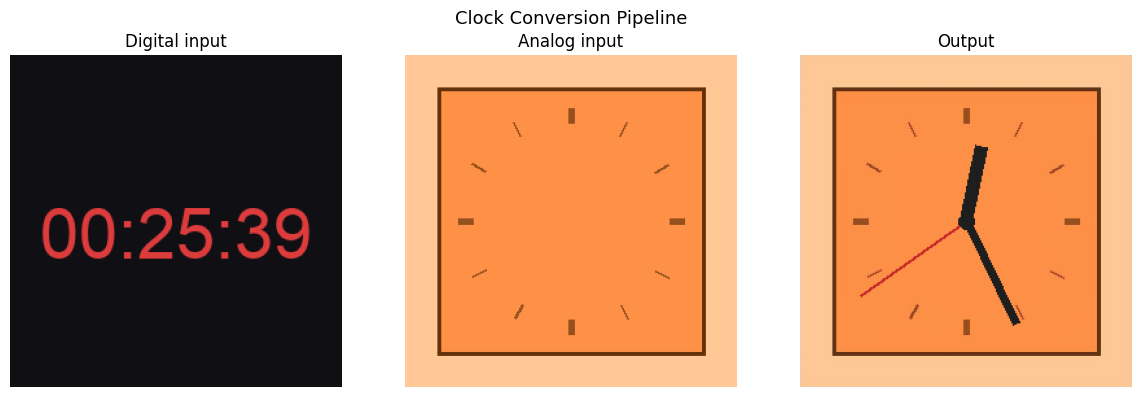

In [9]:
%matplotlib inline

run_single(
    digital_path=DIGITAL_IMG,
    analog_path=ANALOG_IMG,
    output_path='results/output_single.png',
    reader_ckpt=READER_CKPT,
    eraser_ckpt=ERASER_CKPT,
)

## Mode 2 — Batch evaluation (6 random test samples)

Loading pipeline on cpu ...
  [OK] Reader  — src/checkpoints/digital_reader_best.pth
  [OK] Eraser  — src/checkpoints/eraser_v2_best.pth
Pipeline ready.

Saved: results/batch_results.png


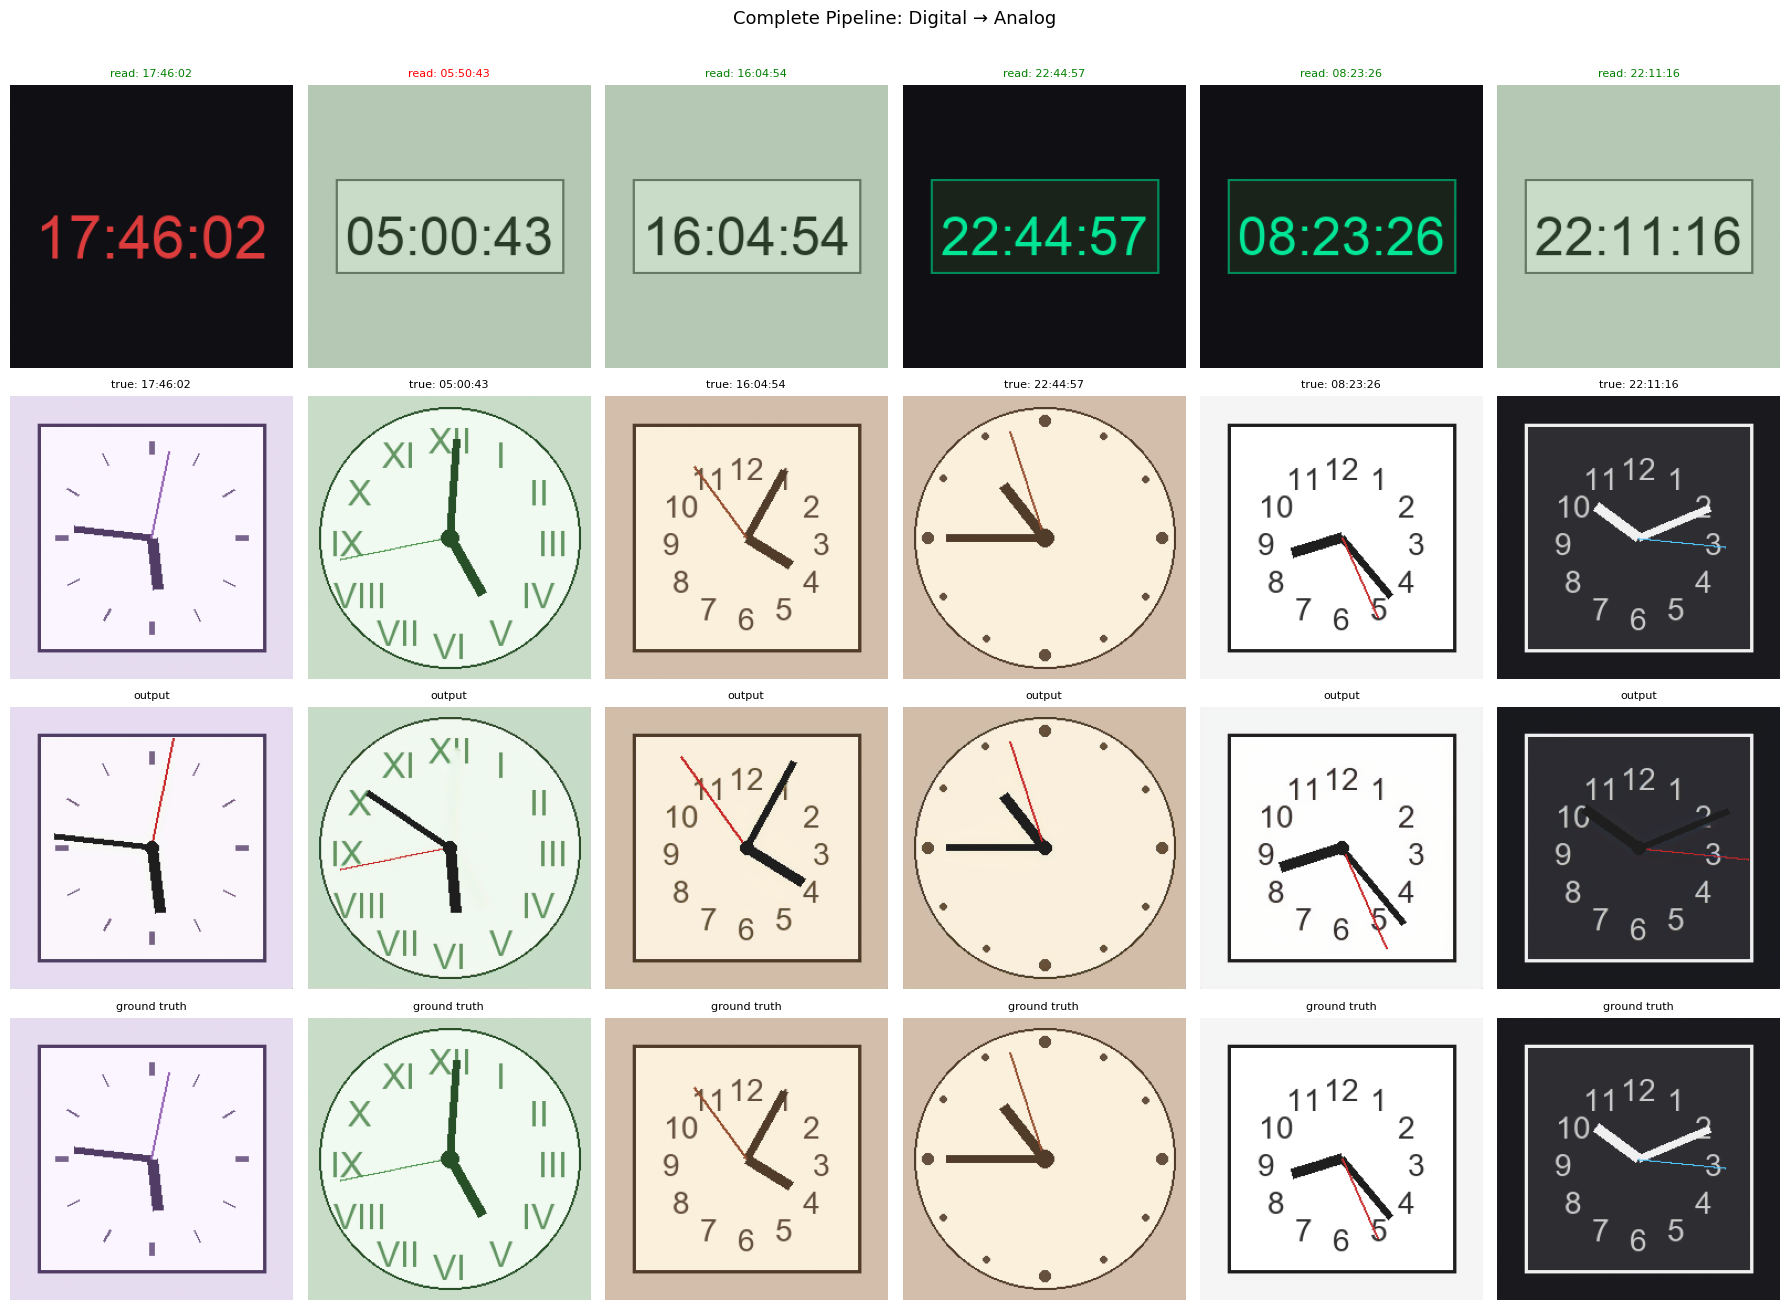

In [10]:
%matplotlib inline

run_batch(
    data_dir=DATA_DIR,
    n=6,
    output_path='results/batch_results.png',
    reader_ckpt=READER_CKPT,
    eraser_ckpt=ERASER_CKPT,
)

## Mode 3 — Live animation *(bonus)*
> Shows the analog clock ticking at real time. Stop with **Interrupt Kernel**.

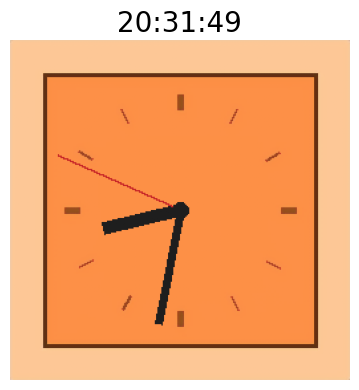

In [12]:
%matplotlib inline
import time
import torch
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from datetime import datetime
from torchvision import transforms
from PIL import Image
from pipeline.full_pipeline import ClockPipeline, _eraser_transform
from pipeline.draw_hand import draw_hands_on_tensor

pipe = ClockPipeline(READER_CKPT, ERASER_CKPT)

analog_pil = Image.open(ANALOG_IMG).convert('RGB')
ana_t = _eraser_transform(analog_pil).unsqueeze(0)
with torch.no_grad():
    clean_t = pipe.eraser(ana_t)

print("Running for 10 seconds — interrupt kernel to stop early.")
for _ in range(10):
    now = datetime.now()
    h, m, s = now.hour, now.minute, now.second

    frame_t = draw_hands_on_tensor(
        clean_t.cpu(),
        torch.tensor([h]), torch.tensor([m]), torch.tensor([s])
    )
    frame_np = frame_t[0].permute(1, 2, 0).clamp(0, 1).numpy()

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(frame_np)
    ax.set_title(f"{h:02d}:{m:02d}:{s:02d}", fontsize=20)
    ax.axis('off')
    plt.tight_layout()

    clear_output(wait=True)
    display(fig)
    plt.close(fig)
    time.sleep(1)